In [2]:
!pip install ultralytics
!pip install seaborn scikit-learn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KYbXdNf0lNqZYN7EFwJD")
project = rf.workspace("object-detection-p6re0").project("ppe-detection-qlq3d-41ywt")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-detection-1 in yolov8:: 100%|██████████| 24680/24680 [00:04<00:00, 5288.44it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from ultralytics import YOLO

# Load pretrained model
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data="/content/PPE-detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [5]:
metrics = model.val(
    data="/content/PPE-detection-1/data.yaml",
    batch=16,
    imgsz=640
)

print("Precision:", metrics.box.p)
print("Recall:", metrics.box.r)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2141.0±497.5 MB/s, size: 71.6 KB)
val: Scanning /content/PPE-detection-1/valid/labels.cache... 1026 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1026/1026 391.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 36, len(boxes) = 4307. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 65/65 6.1it/s 10.6s
                   all       1026       4307      0.449      0.588      0.517      0.316
                 boots        439        931      0.809      0.916      0.925      0.703
                gloves        1

In [12]:
results = model.predict(
    source="/content/PPE-detection-1/valid/images",
    batch=16
)


image 1/1026 /content/PPE-detection-1/valid/images/00000383_jpg.rf.2517faadd0a6ccc60756cb4ac2790047.jpg: 640x640 3 bootss, 1 helmet, 2 vests, 4.4ms
image 2/1026 /content/PPE-detection-1/valid/images/00004_jpg.rf.290735c50921104b885998eabf812f54.jpg: 640x640 1 no-helmet, 1 vest, 4.4ms
image 3/1026 /content/PPE-detection-1/valid/images/00004_jpg.rf.7e8f682218be31f0694c98f638210358.jpg: 640x640 1 vest, 4.4ms
image 4/1026 /content/PPE-detection-1/valid/images/00011_jpg.rf.521d05071bc9967595df2652b233dd6d.jpg: 640x640 1 no-helmet, 2 vests, 4.4ms
image 5/1026 /content/PPE-detection-1/valid/images/00014_jpg.rf.3204b73570738780fd49edee32e75a52.jpg: 640x640 1 helmet, 1 no-goggles, 2 vests, 4.4ms
image 6/1026 /content/PPE-detection-1/valid/images/00035_jpg.rf.518baa438aa1d784873b07a730df560c.jpg: 640x640 1 helmet, 1 no-helmet, 1 vest, 4.4ms
image 7/1026 /content/PPE-detection-1/valid/images/00037_jpg.rf.a30a15fff196a1cd9859a02e7790dcee.jpg: 640x640 1 vest, 4.4ms
image 8/1026 /content/PPE-detect

In [13]:
import os

print(os.listdir("/content/PPE-detection-1/valid/images")[:10])

['image_172_jpg.rf.681b99d05a36dd10cf0c369da514b335.jpg', 'Video4_273_jpg.rf.bd48fa336049eb770561d4862c058747.jpg', 'Video2_40_jpg.rf.115d8bf01c36d1daf64d16e4f9efe5d5.jpg', 'Video1_191_jpg.rf.353997ab41c86e90d4cb2476ece9c22c.jpg', 'ppe_0872_jpg.rf.ddf9a9e25c6421f087d77cb52e29c9ed.jpg', 'ppe_0687_jpg.rf.cc5e03db804b038b218ef8009a4048e2.jpg', 'ppe_0512_jpg.rf.b81190527eb826fe7f4b8200b80417a6.jpg', 'Video1_2_jpg.rf.f31926ea751798fb7c927a36a9e11455.jpg', 'image_247_jpg.rf.1fb30c681afa8b09ef1f326e1943b5f3.jpg', 'Video4_246_jpg.rf.3f6d82d1ca844132c0736f0906314c94.jpg']


In [14]:
import os

os.listdir("/content/PPE-detection-1")

['README.dataset.txt',
 'data.yaml',
 'valid',
 'test',
 'README.roboflow.txt',
 'train']

FileNotFoundError: No such file or directory: 'runs/detect/train/PR_curve.png'

FileNotFoundError: No such file or directory: 'runs/detect/train/PR_curve.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: 'runs/detect/train/F1_curve.png'

FileNotFoundError: No such file or directory: 'runs/detect/train/F1_curve.png'

...

FileNotFoundError: No such file or directory: 'runs/detect/train/P_curve.png'

<IPython.core.display.Image object>

FileNotFoundError: No such file or directory: 'runs/detect/train/R_curve.png'

FileNotFoundError: No such file or directory: 'runs/detect/train/R_curve.png'

<IPython.core.display.Image object>

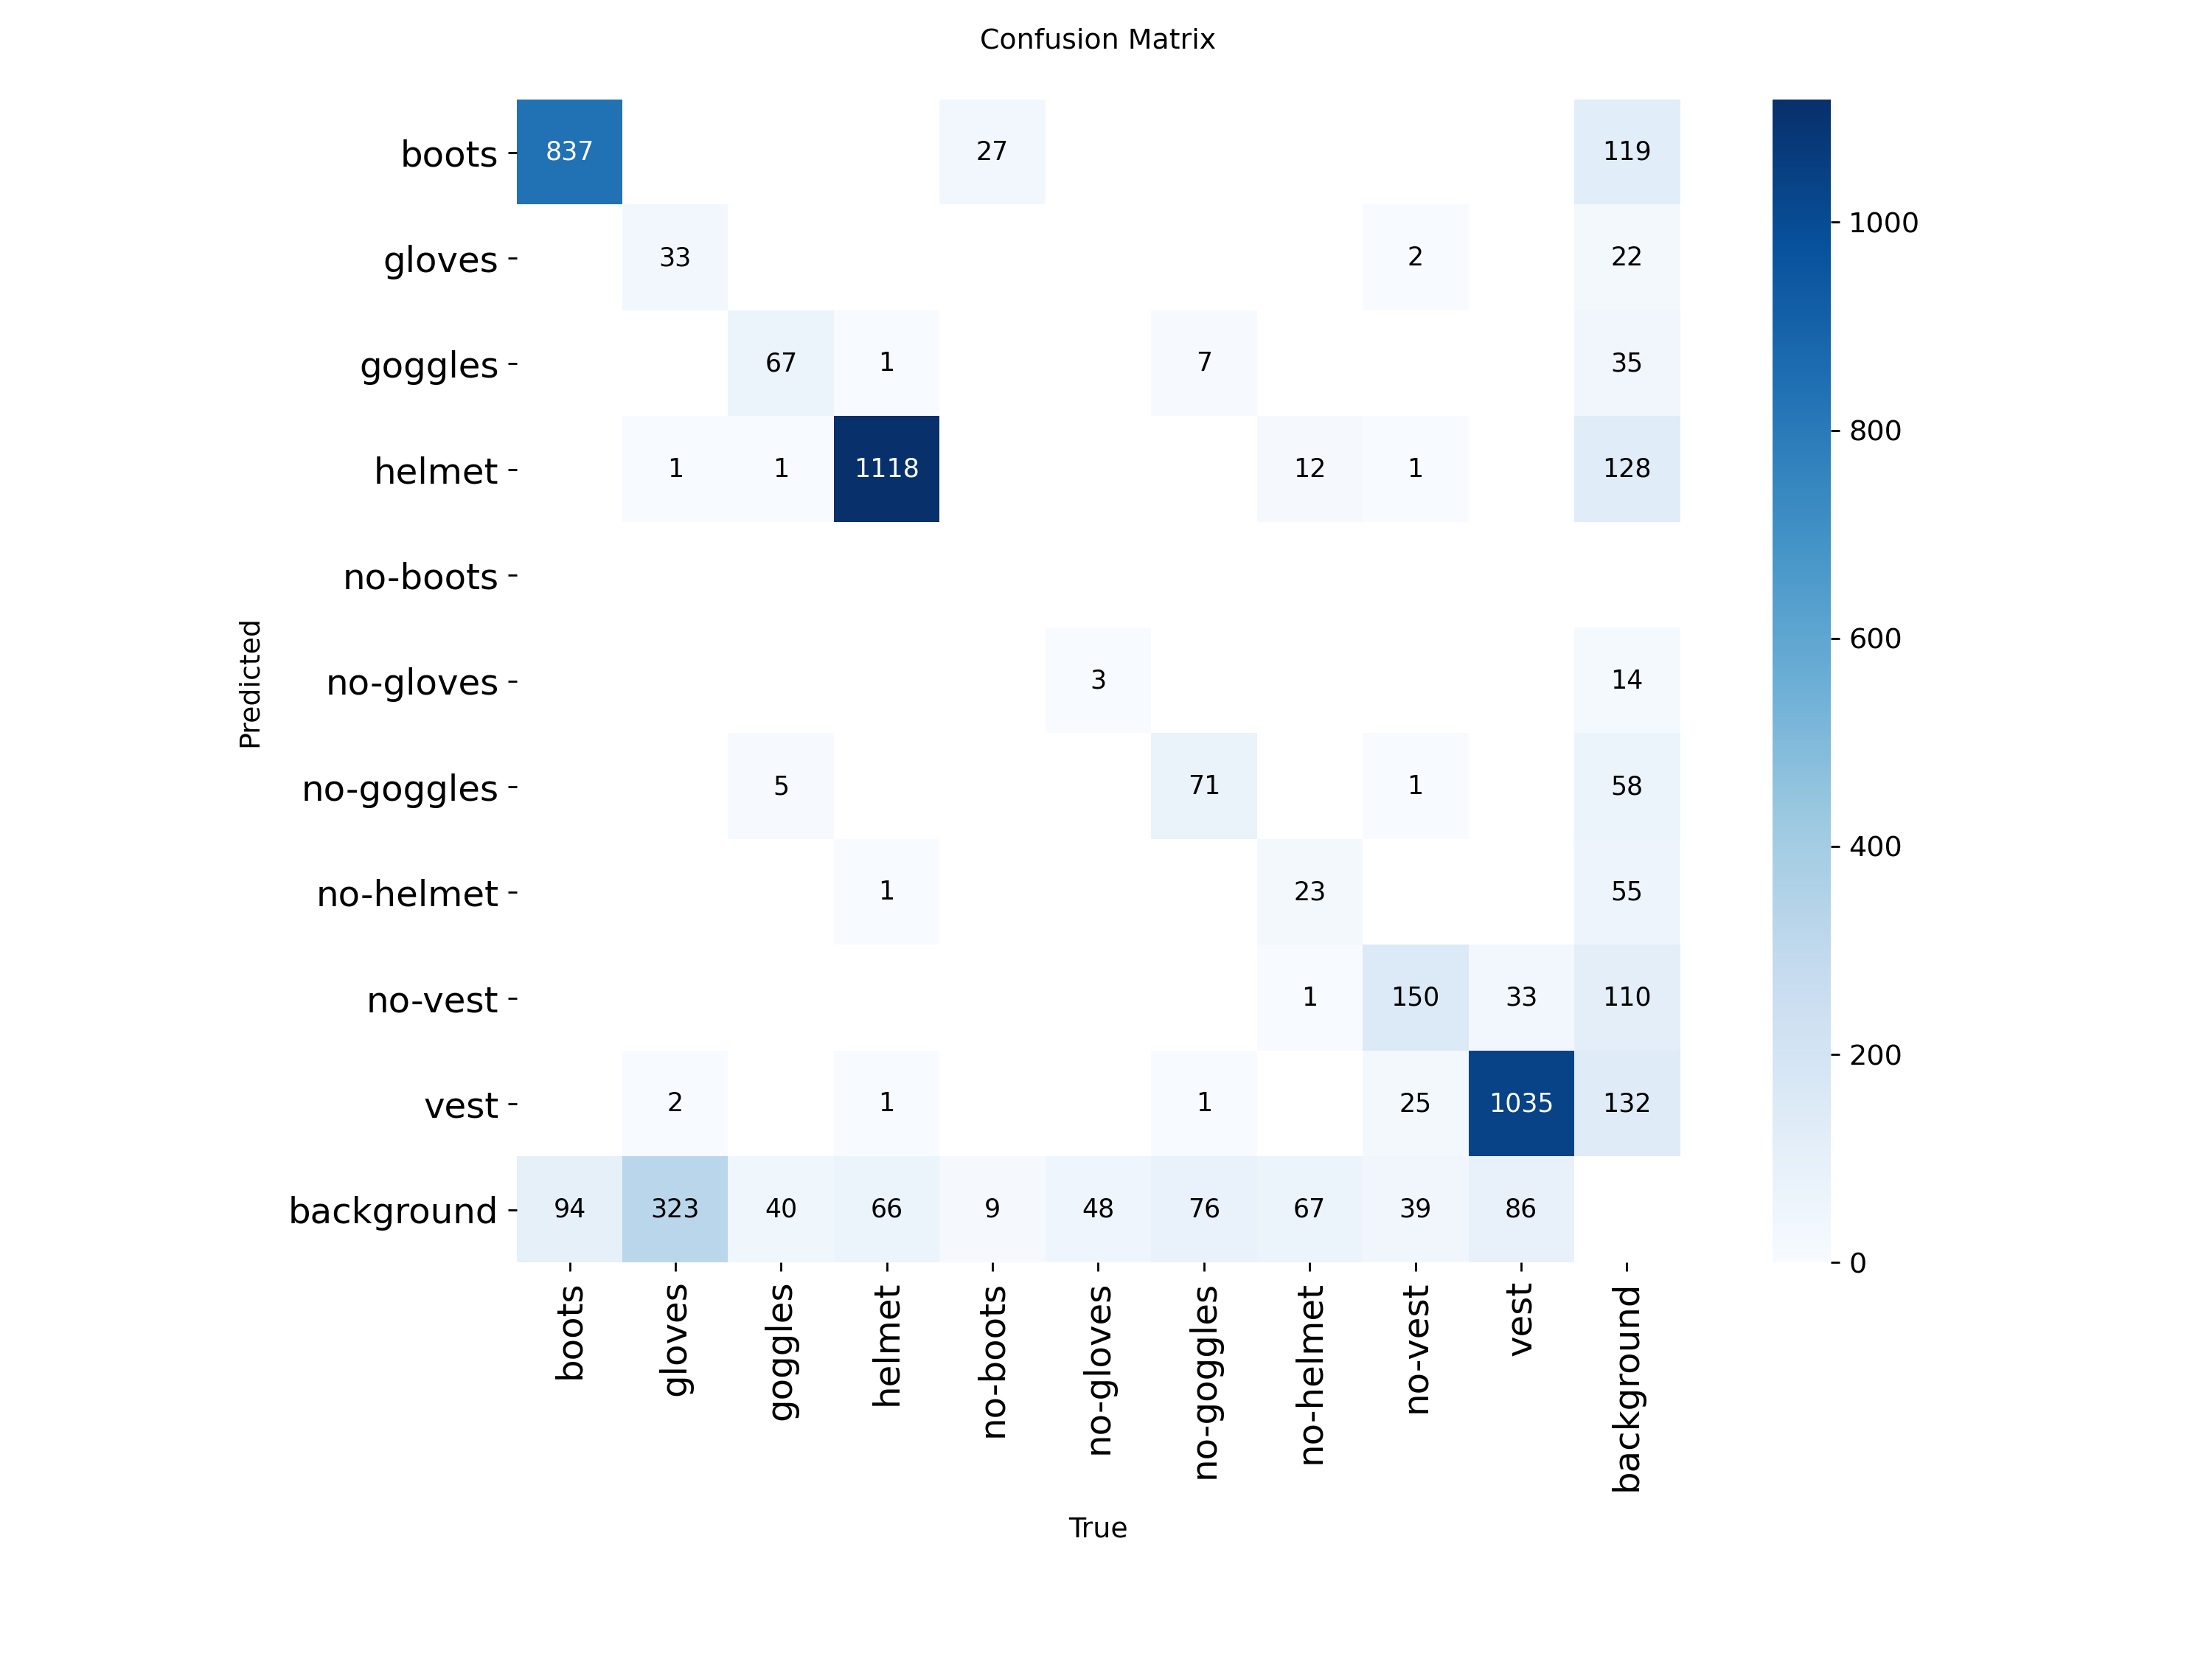

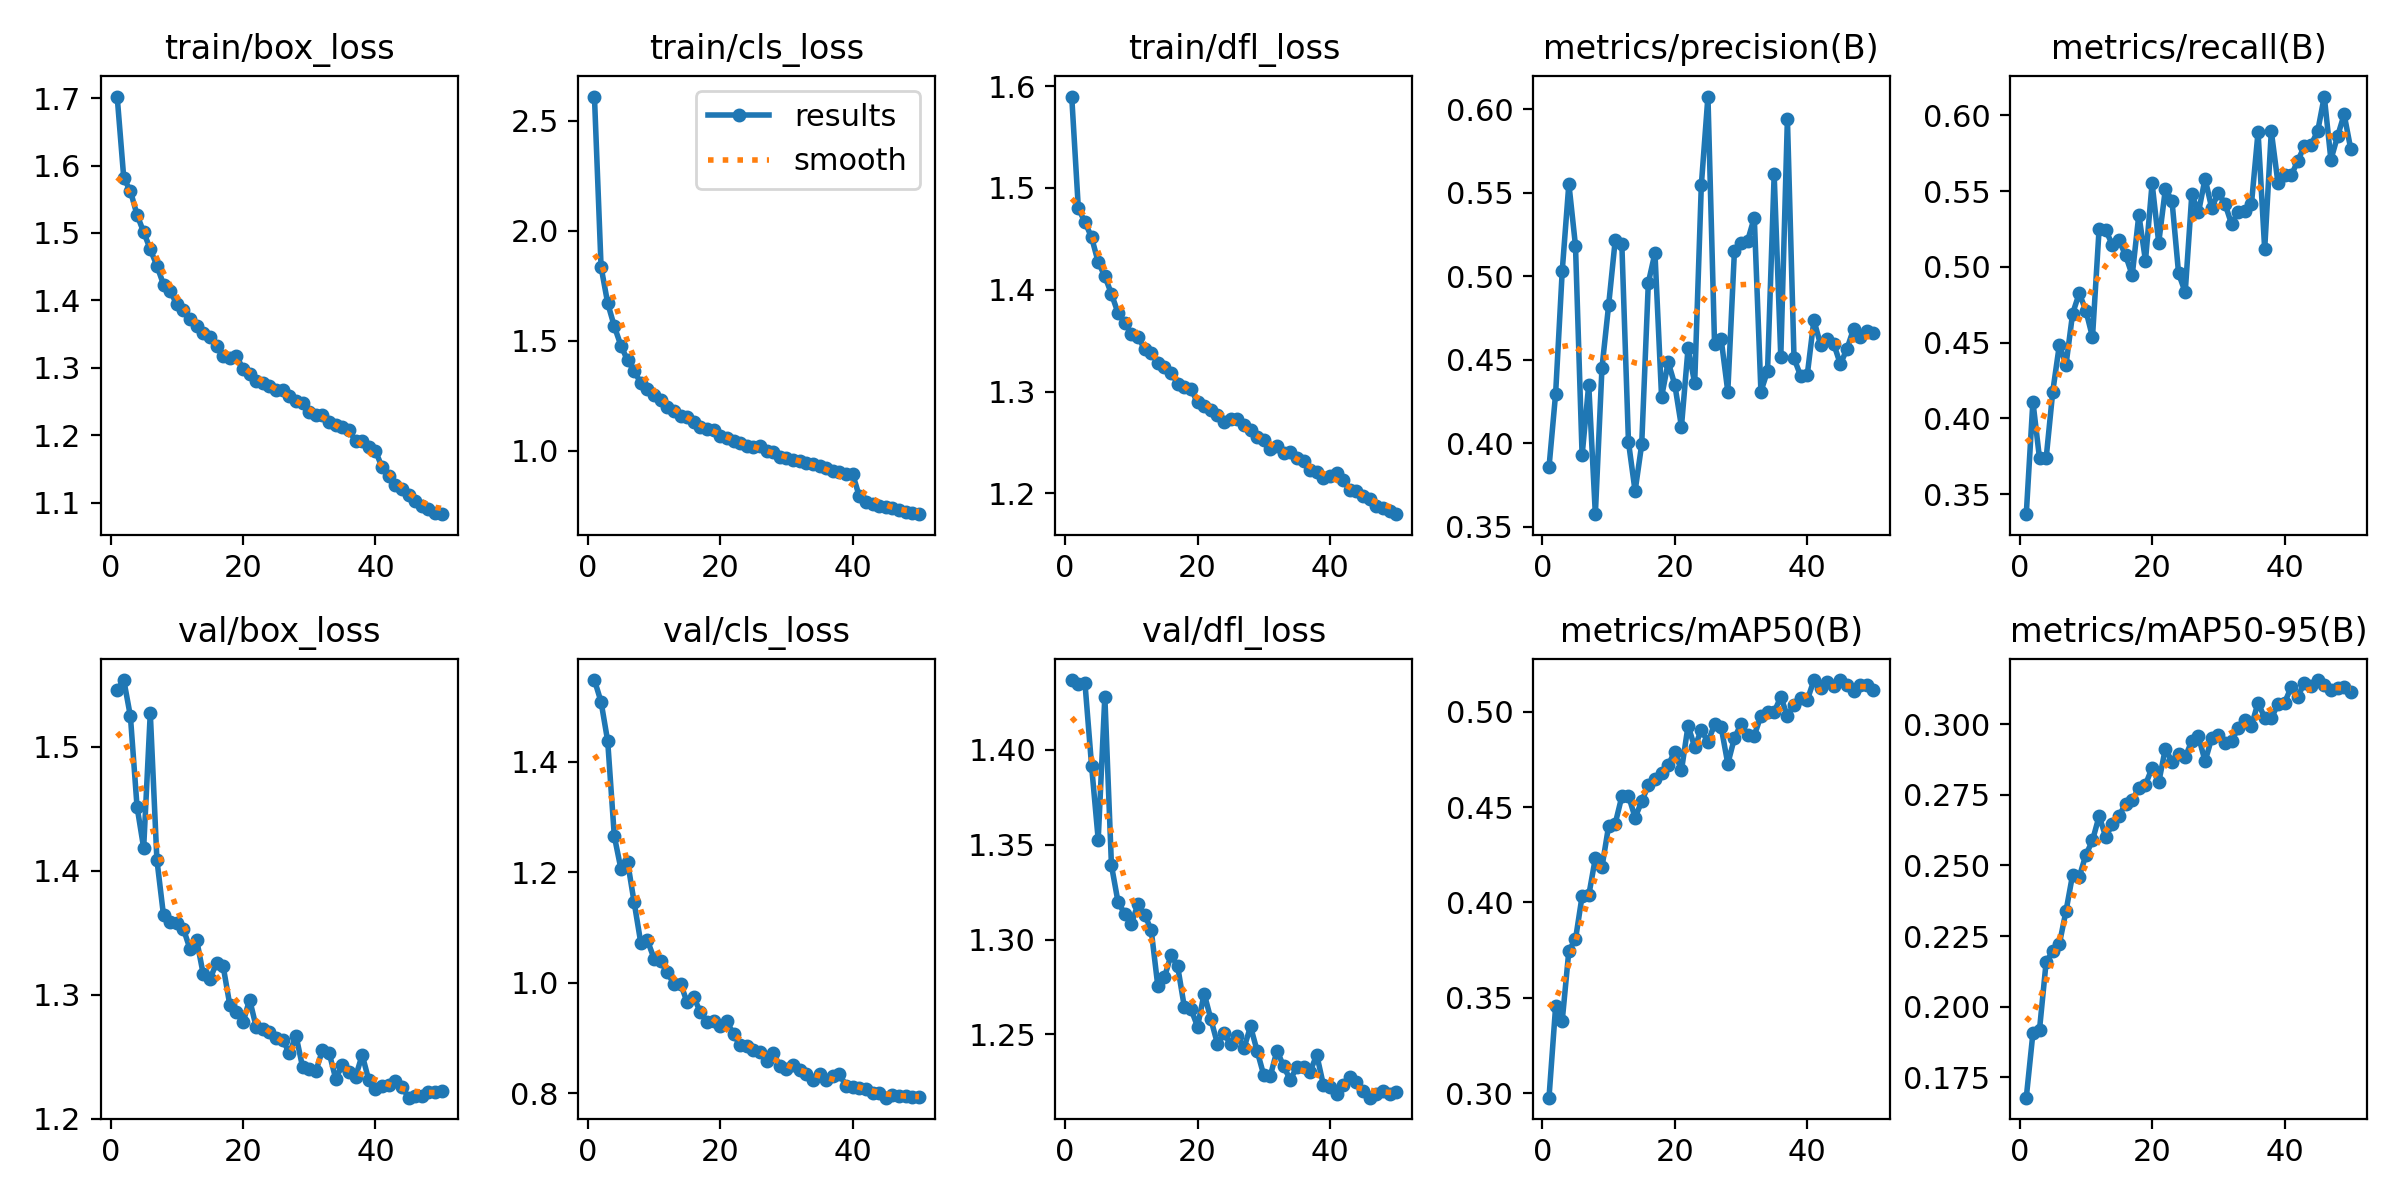

In [15]:
from IPython.display import Image, display

display(Image("runs/detect/train/PR_curve.png"))
display(Image("runs/detect/train/F1_curve.png"))
display(Image("runs/detect/train/P_curve.png"))
display(Image("runs/detect/train/R_curve.png"))
display(Image("runs/detect/train/confusion_matrix.png"))
display(Image("runs/detect/train/results.png"))